In [44]:
!pip install vaderSentiment
!pip install flair
!pip install TextBlob
!pip install ipywidgets


zsh:1: /Users/Licas/Desktop/cours + projets/NLP/nlpenv/bin/pip: bad interpreter: /Users/Licas/Desktop/NLP/nlpenv/bin/python3.13: no such file or directory

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.13/bin/python3 -m pip install --upgrade pip
zsh:1: /Users/Licas/Desktop/cours + projets/NLP/nlpenv/bin/pip: bad interpreter: /Users/Licas/Desktop/NLP/nlpenv/bin/python3.13: no such file or directory

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.13/bin/python3 -m pip install --upgrade pip
zsh:1: /Users/Licas/Desktop/cours + projets/NLP/nlpenv/bin/pip: bad interpreter: /Users/Licas/Desktop/NLP/nlpenv/bin/python3.13: no such file or directory

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.13/bin/python3 -m pip install --upgrade pip
zsh:

In [45]:
# Import the necessary libraries/packages
# Data processing

import sys
import subprocess
# Force l'installation dans le Python EXACT qui exécute ce notebook/script
# Force l'installation de VADER et de Flair dans ton environnement virtuel
subprocess.check_call([sys.executable, "-m", "pip", "install", "vaderSentiment", "flair", "TextBlob"])

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
tqdm.pandas()

# Import TextBlob
from textblob import TextBlob
from textblob import Blobber
from textblob.sentiments import NaiveBayesAnalyzer

# Import VADER sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Import flair pre-trained sentiment model
from flair.models import TextClassifier
classifier = TextClassifier.load('en-sentiment')

# Import flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set a wider colwith
pd.set_option('display.max_colwidth', 1000)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [46]:
# Read in data
hotel_reviews = pd.read_csv('tripadvisor_hotel_reviews.csv', sep=',', names=['review', 'rating'])

hotel_reviews = hotel_reviews.sample(n=500, random_state=42).copy()

# Take a look at the data
hotel_reviews.head(10)

,review,rating
10726,"place park suv alex ima perfect hosts, breakfast great, places stayed europe jupiter best, hotel gone new beautiful flower arrangements ima arranges daily showers drywall new elevator, great location centrum area transportation, beds good air conditioning, hope amsterdam stay,",5
14919,"stylish hotel great location great stylish hotel fantastic interior design, comfy beds.lovely modern bathrooms nice additional toiletries.free internet bonus.walking distance plaza catalunya great shopping, minutes 2 metro stops,",5
19098,"great location arrived peninsula excelsior 3am, check-in clerk indicated wait 20 minutes staff readied new room burst pipe floor reserved room, old room peninsula tower new room excelsior tower suspect worked favor, excelsior tower room quite nice, spacious comfortable, clearly older hotel maintained kept quite clean, breakfast not included room price quite expensive.we n't asked better location, easy walk marina shopping tourist sites,",4
2450,"wonderful honeymoon wife 29 26 spent honeymoon ritz treated kindly respectfully entire stay days, selected club level enjoy various food presentations disappointed food concierges polite knowledgeable eager recommend excursions restaurants cool lounges/clubs, reynaldo malave club supervisor exceptional talent assisted nightly suggestions reservations, spent time pool beach, relaxing breeze beach gale force times, gym adequate aerobics weight lifting massages received spa superb on-site restaurants impressive casino provided nice distraction night, 29-year-old washington d.c. say comfortably know exceptional service fine food, receive ritz, want 24-hour party atmosphere walk blocks el san juan hotel, just sure make ritz base camp,",5
960,"wonderful location lots extra value, great location lots extras, water bottles room complimentary, complimentary wine reception 5 6 pm night..great way meet guest parts world, like europeans staying complete continental breakfast helpful staff restaurants transportation, told staff worked 20 years, quite testament hotel/owners, small room hotel totally re-furbished 04 great bed linens small clean really need, 1/2 block union square street car line not ask 129.00 night, awesome,",5
17525,"wow, time new york booked trip based recommendations not disappointed.in fact husband said n't picked better place, location fantastic.walking distance attractions convenient stores subway etc.the bellman helpful getting cabs easy going, enjoyed huge room amentities, thing did n't understand hotel quality making pay internet service lounge, needed check email places free.add fact slow dial service disappointment affinia 50.otherwise excellent choice new york,",5
13241,"hotel class, stayed hotel 9/19-9/24 say wonderful hotel, booked holiday inn fishermans wharf mixed reviews site cancelled iam glad did, argonaut run modern pristine hotel, de-luxe room overlooking cable car turnaround golden gate bridge distance, room quite larger expected beds comfortable mini bar did not use shops nearby, pet friendly hotel dog did stay 3 rooms did not hear morning did elephant staying thumping floor.thehotel situated quiet end f/wharf away touristy town, cable car 1 minute walk away plan ride early lines huge.each morning lay free starbucks free wine tasting session evening lovely touch, did venture holiday inn meeting say did clean pleasant hotel glad changed argonaut, visit san francisco hotel helped make fantastic holiday bet,",5
12134,"not hoped having read good trip adviser reviews booked atrium room package hotel website, disappointed room old fashioned tv poor reception dark wooden noisy cabinet hotels rating stayed sydney plasma lcd, view alleyway not expected, nice bathroom comfy beds, breakfast room downstairs like eating cellar, good location easy walk rocks shopping, stay probably not pick hotel rocks decent view,",3
15123,"decent comfortable located hotel, stayed ana hotel tokyo march comfortable clean, paid 19,500 yen night standar

In [47]:
# Get the dataset information
hotel_reviews.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 10726 to 18467
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  500 non-null    str  
 1   rating  500 non-null    str  
dtypes: str(2)
memory usage: 11.7 KB


In [48]:
# Check the label distribution
hotel_reviews['rating'].value_counts()

rating
5    229
4    151
1     42
2     40
3     38
Name: count, dtype: int64

In [49]:
# we add a "label" column with 0 as "bad experience" and 1 as "good experience"

# 1. On force la conversion de la colonne rating en nombres (type float ou int)
# L'argument errors='coerce' transformera les éventuels textes bizarres ou vides en NaN pour éviter de faire planter le code
hotel_reviews['rating'] = pd.to_numeric(hotel_reviews['rating'], errors='coerce')

# 2. On retire les notes moyennes (3) pour avoir un problème binaire net (Positif vs Négatif)
hotel_reviews = hotel_reviews[hotel_reviews['rating'] != 3].copy()

# 3. On labellise à '1' les notes au dessus de 2 et à '0' celles qui sont en dessous.
hotel_reviews['label'] = np.where(hotel_reviews['rating'] >= 2, 1, 0)

hotel_reviews.head(10)

,review,rating,label
10726,"place park suv alex ima perfect hosts, breakfast great, places stayed europe jupiter best, hotel gone new beautiful flower arrangements ima arranges daily showers drywall new elevator, great location centrum area transportation, beds good air conditioning, hope amsterdam stay,",5,1
14919,"stylish hotel great location great stylish hotel fantastic interior design, comfy beds.lovely modern bathrooms nice additional toiletries.free internet bonus.walking distance plaza catalunya great shopping, minutes 2 metro stops,",5,1
19098,"great location arrived peninsula excelsior 3am, check-in clerk indicated wait 20 minutes staff readied new room burst pipe floor reserved room, old room peninsula tower new room excelsior tower suspect worked favor, excelsior tower room quite nice, spacious comfortable, clearly older hotel maintained kept quite clean, breakfast not included room price quite expensive.we n't asked better location, easy walk marina shopping tourist sites,",4,1
2450,"wonderful honeymoon wife 29 26 spent honeymoon ritz treated kindly respectfully entire stay days, selected club level enjoy various food presentations disappointed food concierges polite knowledgeable eager recommend excursions restaurants cool lounges/clubs, reynaldo malave club supervisor exceptional talent assisted nightly suggestions reservations, spent time pool beach, relaxing breeze beach gale force times, gym adequate aerobics weight lifting massages received spa superb on-site restaurants impressive casino provided nice distraction night, 29-year-old washington d.c. say comfortably know exceptional service fine food, receive ritz, want 24-hour party atmosphere walk blocks el san juan hotel, just sure make ritz base camp,",5,1
960,"wonderful location lots extra value, great location lots extras, water bottles room complimentary, complimentary wine reception 5 6 pm night..great way meet guest parts world, like europeans staying complete continental breakfast helpful staff restaurants transportation, told staff worked 20 years, quite testament hotel/owners, small room hotel totally re-furbished 04 great bed linens small clean really need, 1/2 block union square street car line not ask 129.00 night, awesome,",5,1
17525,"wow, time new york booked trip based recommendations not disappointed.in fact husband said n't picked better place, location fantastic.walking distance attractions convenient stores subway etc.the bellman helpful getting cabs easy going, enjoyed huge room amentities, thing did n't understand hotel quality making pay internet service lounge, needed check email places free.add fact slow dial service disappointment affinia 50.otherwise excellent choice new york,",5,1
13241,"hotel class, stayed hotel 9/19-9/24 say wonderful hotel, booked holiday inn fishermans wharf mixed reviews site cancelled iam glad did, argonaut run modern pristine hotel, de-luxe room overlooking cable car turnaround golden gate bridge distance, room quite larger expected beds comfortable mini bar did not use shops nearby, pet friendly hotel dog did stay 3 rooms did not hear morning did elephant staying thumping floor.thehotel situated quiet end f/wharf away touristy town, cable car 1 minute walk away plan ride early lines huge.each morning lay free starbucks free wine tasting session evening lovely touch, did venture holiday inn meeting say did clean pleasant hotel glad changed argonaut, visit san francisco hotel helped make fantastic holiday bet,",5,1
15123,"decent comfortable located hotel, stayed ana hotel tokyo march comfortable clean, paid 19,500 yen night standard twin room 26th 22nd floors stayed nights initially nights week later, rooms pleasantly decorated neutral western style good lighting comfortable beds duvets flat screen tv, particular beds extremely comfortable, whilst not huge design inclusion small seating area large window providing great views imperial palace diet building room tokyo tower roppongi gave sense space, bathrooms

# TextBlob Pipeline 

In [50]:
# La polarité de TextBlob va de -1 à +1. Si c'est supérieur ou égal à 0, on considère cela positif (1), sinon négatif (0).
hotel_reviews['scores_TextBlob'] = hotel_reviews['review'].apply(lambda s: TextBlob(str(s)).sentiment.polarity)
hotel_reviews['pred_textBlob'] = hotel_reviews['scores_TextBlob'].apply(lambda x: 1 if x >= 0 else 0)

hotel_reviews.head(10)

,review,rating,label,scores_TextBlob,pred_textBlob
10726,"place park suv alex ima perfect hosts, breakfast great, places stayed europe jupiter best, hotel gone new beautiful flower arrangements ima arranges daily showers drywall new elevator, great location centrum area transportation, beds good air conditioning, hope amsterdam stay,",5,1,0.602525,1
14919,"stylish hotel great location great stylish hotel fantastic interior design, comfy beds.lovely modern bathrooms nice additional toiletries.free internet bonus.walking distance plaza catalunya great shopping, minutes 2 metro stops,",5,1,0.575000,1
19098,"great location arrived peninsula excelsior 3am, check-in clerk indicated wait 20 minutes staff readied new room burst pipe floor reserved room, old room peninsula tower new room excelsior tower suspect worked favor, excelsior tower room quite nice, spacious comfortable, clearly older hotel maintained kept quite clean, breakfast not included room price quite expensive.we n't asked better location, easy walk marina shopping tourist sites,",4,1,0.363939,1
2450,"wonderful honeymoon wife 29 26 spent honeymoon ritz treated kindly respectfully entire stay days, selected club level enjoy various food presentations disappointed food concierges polite knowledgeable eager recommend excursions restaurants cool lounges/clubs, reynaldo malave club supervisor exceptional talent assisted nightly suggestions reservations, spent time pool beach, relaxing breeze beach gale force times, gym adequate aerobics weight lifting massages received spa superb on-site restaurants impressive casino provided nice distraction night, 29-year-old washington d.c. say comfortably know exceptional service fine food, receive ritz, want 24-hour party atmosphere walk blocks el san juan hotel, just sure make ritz base camp,",5,1,0.310185,1
960,"wonderful location lots extra value, great location lots extras, water bottles room complimentary, complimentary wine reception 5 6 pm night..great way meet guest parts world, like europeans staying complete continental breakfast helpful staff restaurants transportation, told staff worked 20 years, quite testament hotel/owners, small room hotel totally re-furbished 04 great bed linens small clean really need, 1/2 block union square street car line not ask 129.00 night, awesome,",5,1,0.335897,1
17525,"wow, time new york booked trip based recommendations not disappointed.in fact husband said n't picked better place, location fantastic.walking distance attractions convenient stores subway etc.the bellman helpful getting cabs easy going, enjoyed huge room amentities, thing did n't understand hotel quality making pay internet service lounge, needed check email places free.add fact slow dial service disappointment affinia 50.otherwise excellent choice new york,",5,1,0.230606,1
13241,"hotel class, stayed hotel 9/19-9/24 say wonderful hotel, booked holiday inn fishermans wharf mixed reviews site cancelled iam glad did, argonaut run modern pristine hotel, de-luxe room overlooking cable car turnaround golden gate bridge distance, room quite larger expected beds comfortable mini bar did not use shops nearby, pet friendly hotel dog did stay 3 rooms did not hear morning did elephant staying thumping floor.thehotel situated quiet end f/wharf away touristy town, cable car 1 minute walk away plan ride early lines huge.each morning lay free starbucks free wine tasting session evening lovely touch, did venture holiday inn meeting say did clean pleasant hotel glad changed argonaut, visit san francisco hotel helped make fantastic holiday bet,",5,1,0.337500,1
15123,"decent comfortable located hotel, stayed ana hotel tokyo march comfortable clean, paid 19,500 yen night standard twin room 26th 22nd floors stayed nights initially nights week later, rooms pleasantly decorated neutral western style good lighting comfortable beds duvets flat screen tv, particular beds extremely comfortable, whilst not huge design inclusion small seating area large windo

In [51]:
# let's compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score

actual_labels = hotel_reviews['label']
predicted_labels = hotel_reviews['pred_textBlob']

accuracy_TextBlob = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_TextBlob = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob)
print(f'Precision:', precision_TextBlob)
print(f'Recall:', recall_TextBlob)
print(f'F1:', f1_TextBlob)

Accuracy: 0.9393939393939394
Precision: 0.8435185185185186
Recall: 0.7523809523809524
F1: 0.7891236306729265


# TextBlob et Naive Bayes

In [52]:
# 1. Ta fonction Naive Bayes nettoyée
def naive_bayes_sentiment(text):
    blob = TextBlob(str(text), analyzer=NaiveBayesAnalyzer())
    return blob.sentiment.classification

# 2. Application STANDARD (on a enlevé .progress_apply)
# Ton notebook ne cherchera plus "IProgress" et l'erreur va disparaître
hotel_reviews['naive_bayes_analysis'] = hotel_reviews['review'].apply(naive_bayes_sentiment)

# 3. Encodage binaire
hotel_reviews['pred_TextBlob_NaiveBayes'] = hotel_reviews['naive_bayes_analysis'].apply(lambda x: 1 if x == 'pos' else 0)

# 4. Affichage du résultat
hotel_reviews[['review', 'label', 'naive_bayes_analysis', 'pred_TextBlob_NaiveBayes']].head()

,review,label,naive_bayes_analysis,pred_TextBlob_NaiveBayes
10726,"place park suv alex ima perfect hosts, breakfast great, places stayed europe jupiter best, hotel gone new beautiful flower arrangements ima arranges daily showers drywall new elevator, great location centrum area transportation, beds good air conditioning, hope amsterdam stay,",1,pos,1
14919,"stylish hotel great location great stylish hotel fantastic interior design, comfy beds.lovely modern bathrooms nice additional toiletries.free internet bonus.walking distance plaza catalunya great shopping, minutes 2 metro stops,",1,pos,1
19098,"great location arrived peninsula excelsior 3am, check-in clerk indicated wait 20 minutes staff readied new room burst pipe floor reserved room, old room peninsula tower new room excelsior tower suspect worked favor, excelsior tower room quite nice, spacious comfortable, clearly older hotel maintained kept quite clean, breakfast not included room price quite expensive.we n't asked better location, easy walk marina shopping tourist sites,",1,neg,0
2450,"wonderful honeymoon wife 29 26 spent honeymoon ritz treated kindly respectfully entire stay days, selected club level enjoy various food presentations disappointed food concierges polite knowledgeable eager recommend excursions restaurants cool lounges/clubs, reynaldo malave club supervisor exceptional talent assisted nightly suggestions reservations, spent time pool beach, relaxing breeze beach gale force times, gym adequate aerobics weight lifting massages received spa superb on-site restaurants impressive casino provided nice distraction night, 29-year-old washington d.c. say comfortably know exceptional service fine food, receive ritz, want 24-hour party atmosphere walk blocks el san juan hotel, just sure make ritz base camp,",1,pos,1
960,"wonderful location lots extra value, great location lots extras, water bottles room complimentary, complimentary wine reception 5 6 pm night..great way meet guest parts world, like europeans staying complete continental breakfast helpful staff restaurants transportation, told staff worked 20 years, quite testament hotel/owners, small room hotel totally re-furbished 04 great bed linens small clean really need, 1/2 block union square street car line not ask 129.00 night, awesome,",1,pos,1


In [53]:
# 1. On isole les 100 premières lignes pour l'évaluation
hotel_reviews_top100 = hotel_reviews.head(100)

# 2. Extraction des labels réels et des prédictions Naive Bayes
actual_labels = hotel_reviews_top100['label']
predicted_labels = hotel_reviews_top100['pred_TextBlob_NaiveBayes']

# 3. Calcul des métriques de performance
accuracy_TextBlob_NB = accuracy_score(actual_labels, predicted_labels)
precision_TextBlob_NB = precision_score(actual_labels, predicted_labels, average='macro', zero_division=0)
recall_TextBlob_NB = recall_score(actual_labels, predicted_labels, average='macro', zero_division=0)
f1_TextBlob_NB = f1_score(actual_labels, predicted_labels, average='macro', zero_division=0)

# 4. Affichage des scores
print(f'Accuracy TextBlob Naive Bayes (Top 100):', accuracy_TextBlob_NB)
print(f'Precision TextBlob Naive Bayes (Top 100):', precision_TextBlob_NB)
print(f'Recall TextBlob Naive Bayes (Top 100):', recall_TextBlob_NB)
print(f'F1 TextBlob Naive Bayes (Top 100):', f1_TextBlob_NB)

Accuracy TextBlob Naive Bayes (Top 100): 0.92
Precision TextBlob Naive Bayes (Top 100): 0.6357388316151202
Recall TextBlob Naive Bayes (Top 100): 0.5606758832565284
F1 TextBlob Naive Bayes (Top 100): 0.5789473684210527


# VADER pipeline

In [54]:
# 1. Initialisation de VADER
vader_analyzer = SentimentIntensityAnalyzer()

# 2. Calcul du score "compound" sur ton dataset hotel_reviews
hotel_reviews['scores_VADER'] = hotel_reviews['review'].apply(lambda s: vader_analyzer.polarity_scores(str(s))['compound'])

# 3. Prédiction du label (1 si positif ou neutre, 0 si négatif)
hotel_reviews['pred_VADER'] = hotel_reviews['scores_VADER'].apply(lambda x: 1 if x >= 0 else 0)

# 4. Extraction des labels réels et prédits
actual_labels = hotel_reviews['label']
predicted_vader = hotel_reviews['pred_VADER']

# 5. Calcul des métriques de performance
accuracy_VADER = accuracy_score(actual_labels, predicted_vader)
precision_VADER = precision_score(actual_labels, predicted_vader, average='macro')
recall_VADER = recall_score(actual_labels, predicted_vader, average='macro')
f1_VADER = f1_score(actual_labels, predicted_vader, average='macro')

# 6. Affichage des résultats
print(f'Accuracy VADER:', accuracy_VADER)
print(f'Precision VADER:', precision_VADER)
print(f'Recall VADER:', recall_VADER)
print(f'F1 VADER:', f1_VADER)

# Optionnel : un petit aperçu visuel pour valider
hotel_reviews[['rating', 'label', 'scores_VADER', 'pred_VADER']].head()

Accuracy VADER: 0.9307359307359307
Precision VADER: 0.7888755980861244
Recall VADER: 0.8011904761904762
F1 VADER: 0.7948604096131431


,rating,label,scores_VADER,pred_VADER
10726,5,1,0.9794,1
14919,5,1,0.9590,1
19098,4,1,0.9663,1
2450,5,1,0.9899,1
960,5,1,0.9823,1


# Flair pipeline

In [55]:
# 1. Fonction optimisée pour obtenir le label binaire (0 ou 1) directement en une seule passe
def predict_flair_binary(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0  # Sécurité pour les textes vides
    
    sentence = Sentence(str(text))
    classifier.predict(sentence)
    
    # Récupération du label ('POSITIVE' ou 'NEGATIVE')
    value = sentence.labels[0].value
    
    # On fait le mapping directement ici (1 si POSITIVE, sinon 0)
    return 1 if value == 'POSITIVE' else 0

# 2. Application du modèle sur dataset 
hotel_reviews['pred_flair'] = hotel_reviews['review'].apply(predict_flair_binary)

# 3. Extraction des labels réels et prédits
actual_labels = hotel_reviews['label']
predicted_flair = hotel_reviews['pred_flair']

# 4. Calcul des métriques de performance
accuracy_flair = accuracy_score(actual_labels, predicted_flair)
precision_flair = precision_score(actual_labels, predicted_flair, average='macro')
recall_flair = recall_score(actual_labels, predicted_flair, average='macro')
f1_flair = f1_score(actual_labels, predicted_flair, average='macro')

# 5. Affichage des résultats pour Flair
print(f'Accuracy Flair:', accuracy_flair)
print(f'Precision Flair:', precision_flair)
print(f'Recall Flair:', recall_flair)
print(f'F1 Flair:', f1_flair)

# Aperçu du résultat
hotel_reviews[['review', 'label', 'pred_flair']].head()

Accuracy Flair: 0.8571428571428571
Precision Flair: 0.6944444444444444
Recall Flair: 0.9214285714285715
F1 Flair: 0.7373643410852713


,review,label,pred_flair
10726,"place park suv alex ima perfect hosts, breakfast great, places stayed europe jupiter best, hotel gone new beautiful flower arrangements ima arranges daily showers drywall new elevator, great location centrum area transportation, beds good air conditioning, hope amsterdam stay,",1,1
14919,"stylish hotel great location great stylish hotel fantastic interior design, comfy beds.lovely modern bathrooms nice additional toiletries.free internet bonus.walking distance plaza catalunya great shopping, minutes 2 metro stops,",1,1
19098,"great location arrived peninsula excelsior 3am, check-in clerk indicated wait 20 minutes staff readied new room burst pipe floor reserved room, old room peninsula tower new room excelsior tower suspect worked favor, excelsior tower room quite nice, spacious comfortable, clearly older hotel maintained kept quite clean, breakfast not included room price quite expensive.we n't asked better location, easy walk marina shopping tourist sites,",1,1
2450,"wonderful honeymoon wife 29 26 spent honeymoon ritz treated kindly respectfully entire stay days, selected club level enjoy various food presentations disappointed food concierges polite knowledgeable eager recommend excursions restaurants cool lounges/clubs, reynaldo malave club supervisor exceptional talent assisted nightly suggestions reservations, spent time pool beach, relaxing breeze beach gale force times, gym adequate aerobics weight lifting massages received spa superb on-site restaurants impressive casino provided nice distraction night, 29-year-old washington d.c. say comfortably know exceptional service fine food, receive ritz, want 24-hour party atmosphere walk blocks el san juan hotel, just sure make ritz base camp,",1,1
960,"wonderful location lots extra value, great location lots extras, water bottles room complimentary, complimentary wine reception 5 6 pm night..great way meet guest parts world, like europeans staying complete continental breakfast helpful staff restaurants transportation, told staff worked 20 years, quite testament hotel/owners, small room hotel totally re-furbished 04 great bed linens small clean really need, 1/2 block union square street car line not ask 129.00 night, awesome,",1,1


In [56]:
!pip install matplotlib

zsh:1: /Users/Licas/Desktop/cours + projets/NLP/nlpenv/bin/pip: bad interpreter: /Users/Licas/Desktop/NLP/nlpenv/bin/python3.13: no such file or directory

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.13/bin/python3 -m pip install --upgrade pip


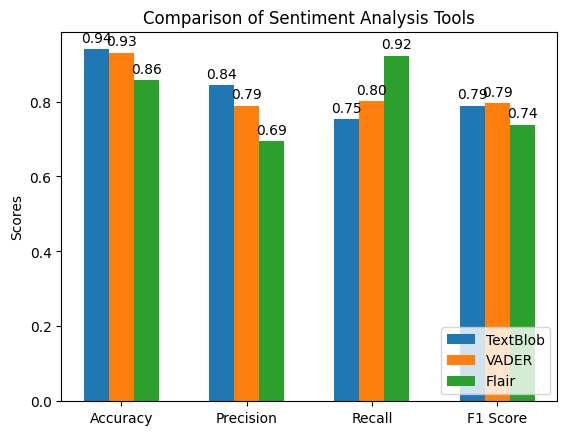

In [57]:
import matplotlib.pyplot as plt

# Conver the results in lists
textblob_values = [accuracy_TextBlob, precision_TextBlob, recall_TextBlob, f1_TextBlob]
# textblobNB_values = [accuracy_TextBlob_NB, precision_TextBlob_NB, recall_TextBlob_NB, f1_TextBlob_NB]
vader_values = [accuracy_VADER, precision_VADER, recall_VADER, f1_VADER]
flair_values = [accuracy_flair, precision_flair, recall_flair, f1_flair]

labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Setting the positions and width for the bars
x = range(len(labels))  # the label locations
width = 0.2  # the width of the bars

# Plotting
fig, ax = plt.subplots()
rects1 = ax.bar(x, textblob_values, width, label='TextBlob')
rects2 = ax.bar([p + width for p in x], vader_values, width, label='VADER')
rects3 = ax.bar([p + width * 2 for p in x], flair_values, width, label='Flair')

# Add some text for labels, title, and custom x-axis tick labels
ax.set_ylabel('Scores')
ax.set_title('Comparison of Sentiment Analysis Tools')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(labels)
ax.legend(loc='lower right')

# Function to add labels on the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Attach labels
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Show the plot
plt.show()


# Analyse comparative — TextBlob, VADER & Flair sur HotelReviews (TripAdvisor)

## Contexte de l'expérimentation

- **Dataset** : `tripadvisor_hotel_reviews.csv` — échantillon aléatoire de **500 avis** (`random_state=42`).
- **Pré-traitement** : suppression des notes neutres (rating = 3) pour obtenir une tâche **binaire** (positif vs négatif).
- **Labellisation** : rating ≥ 2 → `1` (positif), rating < 2 → `0` (négatif).
- **Déséquilibre des classes** : le dataset est **fortement déséquilibré en faveur du positif** (~91 % de 1, ~9 % de 0). C'est un point crucial pour interpréter les métriques.
- **Métriques** : accuracy + precision / recall / F1 en **moyenne macro** (pour que la classe négative, minoritaire, pèse autant que la positive).

---

## Résultats obtenus

| Modèle       | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|--------------|:--------:|:-----------------:|:--------------:|:----------:|
| **TextBlob** |  0.939   |       0.844       |     0.752      |   0.789    |
| **VADER**    |  0.931   |       0.789       |     0.801      | **0.795**  |
| **Flair**    |  0.857   |       0.694       |   **0.921**    |   0.737    |
| **TextBlob + Naive Bayes** † | 0.920 | 0.636 | 0.561 | 0.579 |

† **Évalué sur 100 lignes seulement** (et non 500) : le `NaiveBayesAnalyzer` de TextBlob a un coût d'inférence très élevé. Cette ligne n'est donc **pas directement comparable** aux trois autres — elle est indiquée à titre informatif.

> *Lecture : malgré une accuracy de 0.92 (gonflée par le déséquilibre des classes), son **F1 macro de 0.58** est le plus faible de tous → faible capacité à détecter la classe négative minoritaire dans nos conditions, pour un coût de calcul prohibitif.*

---

## Lecture des résultats

### 1. L'accuracy seule est trompeuse
Avec ~91 % de classe positive, un modèle qui prédirait **toujours positif** obtiendrait déjà ~91 % d'accuracy. C'est pourquoi **TextBlob et VADER affichent ~93 %**, mais l'écart réel se voit dans le **F1 macro**, qui équilibre les deux classes.

### 2. TextBlob — Le « prudent »
- Forte **precision** (0.84) mais **recall** plus faible (0.75) : quand il prédit négatif, il a souvent raison, mais il **rate beaucoup de vrais avis négatifs** (faux négatifs).
- Approche lexicale très simple (somme de polarités de mots). Sensible aux formulations indirectes ou nuancées (« n't asked better », double négation, ironie).

### 3. VADER — Le meilleur compromis
- **F1 macro le plus élevé (0.795)** et profil le plus équilibré (precision ≈ recall).
- Conçu à l'origine pour le langage des **réseaux sociaux**, mais sa gestion des intensificateurs (« great », « very ») et de la ponctuation se transfère bien aux avis hôteliers.
- Rapide, déterministe, sans GPU → idéal en production légère.

### 4. Flair — Le « sensible »
- **Recall très élevé (0.92)** mais **precision faible (0.69)** : il détecte presque tous les avis négatifs, **au prix de nombreux faux positifs négatifs** (il classe en négatif des avis qui ne le sont pas).
- Modèle de deep learning (LSTM pré-entraîné) : capte mieux le contexte et les négations, mais **sur-pondère les signaux négatifs locaux** sur des textes longs.
- Bien plus coûteux en calcul (de loin le plus lent des trois).

---

## Quel modèle choisir selon l'usage ?

| Objectif métier | Modèle recommandé | Pourquoi |
|---|---|---|
| Score global équilibré, rapide | **VADER** | Meilleur F1 macro, léger, sans dépendance lourde |
| Minimiser les fausses alertes négatives (ex. tableau de bord) | **TextBlob** | Meilleure precision sur la classe négative |
| Ne **rater aucun avis négatif** (ex. modération, alertes qualité) | **Flair** | Meilleur recall — quitte à valider manuellement les faux positifs |

---

## Limites de l'expérience et pistes d'amélioration

- **Échantillon de 500** : la classe négative ne représente que ~40 avis → métriques sensibles à la variance d'échantillonnage. À refaire sur l'ensemble du dataset pour confirmer.
- **Seuil de décision figé** (≥ 0 = positif) : un ajustement de seuil sur VADER/TextBlob améliorerait probablement le F1 macro.
- **Pas de pré-traitement linguistique** (lemmatisation, gestion des négations explicites) : un nettoyage ciblé profiterait surtout à TextBlob.
- **TextBlob + NaiveBayes** n'a pu être évalué que sur 100 lignes : non comparable directement aux autres.
- **Pistes** : tester un modèle Transformer (BERT fine-tuné sur reviews), ou un classifieur supervisé léger (logistic regression sur TF-IDF) en baseline.

---

## En une phrase

> Sur HotelReviews, **VADER offre le meilleur équilibre precision/recall pour un coût négligeable**, **TextBlob est plus conservateur**, et **Flair est le plus sensible** mais le plus coûteux — le choix dépend du coût relatif des faux positifs vs faux négatifs dans le cas d'usage.


# Décision finale & réflexion

### 1. Le gagnant
**VADER** l'emporte sur le **F1 macro (0.795)**, devant TextBlob (0.789) et Flair (0.737). Bien que purement lexical, il bat le deep learning ici car nos avis hôteliers reposent surtout sur un vocabulaire d'opinion explicite (« great », « terrible », « clean »), exactement ce que gère son dictionnaire pondéré + ses règles d'intensité/négation. Flair (LSTM), pensé pour du contexte long et nuancé, sur-pondère les signaux négatifs locaux et perd en precision sur ce dataset très positif.

### 2. Le compromis (production, 10 000 req/s, budget serré)
Oui, je **garde VADER** — et c'est même un cas rare où le plus performant est aussi le moins cher. Il est purement basé sur des règles : inférence en microsecondes, déterministe, **sans GPU ni dépendance lourde**, donc trivial à scaler horizontalement à coût quasi nul. Flair, même légèrement meilleur en recall, imposerait du GPU et une latence ~100–1000× supérieure : injustifiable à ce volume. La précision marginale ne vaut pas l'explosion du coût d'infra.

### 3. La prochaine étape (stratégie d'amélioration)
Faiblesse principale de VADER : **recall imparfait sur la classe négative minoritaire** (~9 % des données), à cause d'un **seuil de décision figé** (compound ≥ 0 = positif) et de l'absence de gestion fine des négations indirectes/ironie. Stratégie concrète : **calibrer le seuil** (chercher le point qui maximise le F1 macro plutôt que 0), puis si besoin entraîner une **régression logistique légère sur les scores VADER + features TF-IDF** — on garde la vitesse tout en apprenant la frontière optimale sur notre distribution déséquilibrée.